# 01 — Flow A: Fine-tune on Noisy Audio

Fine-tunes **Whisper-base** + **Wav2Vec2-base-960h** on the **noisy** VoiceBank-DEMAND train split using pseudo-labels from notebook 00.

**Switchable mode** — set `MODE = 'lora'` (default, ~75 min on T4) or `MODE = 'full'` (~3h on T4).

**Inputs (attach to this Kaggle notebook):**
- `vbd-labels-enhanced-train` — produced by notebook 00 (`transcripts.csv` is what we need here).
- `vbd-finetune-code` — a dataset you create from your local `finetuning/train_utils.py` + `eval_utils.py`.

**Output:** push `/kaggle/working/finetuned/noisy/` as Kaggle dataset `vbd-finetuned-noisy`.

In [1]:
# import os
# print('inputs:', os.listdir('/kaggle/input'))
# for d in os.listdir('/kaggle/input'):
#     p = f'/kaggle/input/{d}'
#     print(f'\n{p}:')
#     for root, dirs, files in os.walk(p):
#         for f in files:
#             print(' ', os.path.join(root, f))

In [2]:
MODE = 'full'        # 'lora' (default) or 'full'
CONDITION = 'noisy'  # this notebook is Flow A — do not change
EPOCHS = 5
BSZ = 8
MODELS = ['wav2vec2']   # both by default. Subset to skip a model.
                                    # Examples: ['wav2vec2']  or  ['whisper']

In [3]:
!pip install -q transformers==4.46.* peft==0.13.* accelerate datasets jiwer librosa soundfile

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 70.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 320.7/320.7 kB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 77.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 83.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 95.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.2

In [4]:
import os, sys, torch
os.environ['TRANSFORMERS_VERBOSITY'] = 'error'
assert torch.cuda.is_available(), 'Enable GPU T4 x2.'

# Make our train_utils.py importable
CODE_PATH = '/kaggle/input/notebooks/tejaswagg/vbd-finetune-code'
if CODE_PATH not in sys.path:
    sys.path.insert(0, CODE_PATH)
import train_utils
print('train_utils loaded from:', train_utils.__file__)

train_utils loaded from: /kaggle/input/notebooks/tejaswagg/vbd-finetune-code/train_utils.py


In [5]:
TRANSCRIPTS_CSV = '/kaggle/input/datasets/tejaswagg/vbd-labels-enhanced-train/transcripts.csv'
ENHANCED_DIR    = None  # not used in Flow A
OUT_ROOT        = f'/kaggle/working/finetuned/{CONDITION}'
os.makedirs(OUT_ROOT, exist_ok=True)
print('out:', OUT_ROOT)

out: /kaggle/working/finetuned/noisy


## Run training

`run_training` calls the LoRA or full FT function for each model, writes
checkpoints + `train_log.jsonl` per model under `OUT_ROOT`, and frees GPU
memory between models.

In [6]:
results = train_utils.run_training(
    condition=CONDITION,
    mode=MODE,
    transcripts_csv=TRANSCRIPTS_CSV,
    enhanced_dir=ENHANCED_DIR,
    out_root=OUT_ROOT,
    epochs=EPOCHS,
    bsz=BSZ,
    models=MODELS,
)
print('done. trained:', list(results.keys()))

README.md:   0%|          | 0.00/652 [00:00<?, ?B/s]

data/train-00000-of-00005.parquet:   0%|          | 0.00/444M [00:00<?, ?B/s]

data/train-00001-of-00005.parquet:   0%|          | 0.00/416M [00:00<?, ?B/s]

data/train-00002-of-00005.parquet:   0%|          | 0.00/431M [00:00<?, ?B/s]

data/train-00003-of-00005.parquet:   0%|          | 0.00/444M [00:00<?, ?B/s]

...

{'loss': 121.0092, 'grad_norm': 167458256.0, 'learning_rate': 8.549931600547196e-07, 'epoch': 4.915514592933948}


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector

{'loss': 129.8679, 'grad_norm': 287148928.0, 'learning_rate': 0.0, 'epoch': 4.99231950844854}


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector

{'eval_loss': 79.76154327392578, 'eval_wer': 0.13555222849245652, 'eval_runtime': 39.9533, 'eval_samples_per_second': 28.984, 'eval_steps_per_second': 1.827, 'epoch': 4.99231950844854}
{'train_runtime': 6209.6676, 'train_samples_per_second': 8.385, 'train_steps_per_second': 0.262, 'train_loss': 168.38555258413462, 'epoch': 4.99231950844854}
done. trained: ['wav2vec2']


In [7]:
# Sanity listing
from pathlib import Path
for p in sorted(Path(OUT_ROOT).rglob('*')):
    if p.is_file():
        print(f'{p.relative_to("/kaggle/working")}  ({p.stat().st_size//1024} KB)')

finetuned/noisy/wav2vec2_base_full/checkpoint-1625/config.json  (2 KB)
finetuned/noisy/wav2vec2_base_full/checkpoint-1625/model.safetensors  (368760 KB)
finetuned/noisy/wav2vec2_base_full/checkpoint-1625/optimizer.pt  (704822 KB)
finetuned/noisy/wav2vec2_base_full/checkpoint-1625/rng_state.pth  (14 KB)
finetuned/noisy/wav2vec2_base_full/checkpoint-1625/scheduler.pt  (1 KB)
finetuned/noisy/wav2vec2_base_full/checkpoint-1625/trainer_state.json  (12 KB)
finetuned/noisy/wav2vec2_base_full/checkpoint-1625/training_args.bin  (5 KB)
finetuned/noisy/wav2vec2_base_full/config.json  (2 KB)
finetuned/noisy/wav2vec2_base_full/model.safetensors  (368760 KB)
finetuned/noisy/wav2vec2_base_full/preprocessor_config.json  (0 KB)
finetuned/noisy/wav2vec2_base_full/special_tokens_map.json  (0 KB)
finetuned/noisy/wav2vec2_base_full/tokenizer_config.json  (1 KB)
finetuned/noisy/wav2vec2_base_full/train_log.jsonl  (9 KB)
finetuned/noisy/wav2vec2_base_full/training_args.bin  (5 KB)
finetuned/noisy/wav2vec2_ba

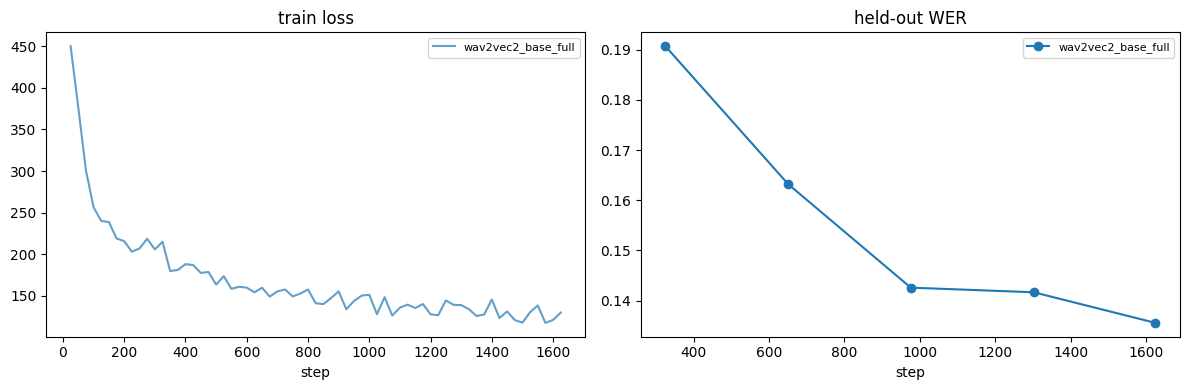

In [8]:
# Quick training-curve preview from train_log.jsonl
import json, matplotlib.pyplot as plt
from pathlib import Path
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for log in Path(OUT_ROOT).rglob('train_log.jsonl'):
    rows = [json.loads(l) for l in open(log) if l.strip()]
    loss = [(r['step'], r['loss']) for r in rows if 'loss' in r]
    wer  = [(r['step'], r['eval_wer']) for r in rows if 'eval_wer' in r]
    label = log.parent.name
    if loss: axes[0].plot(*zip(*loss), label=label, alpha=0.7)
    if wer:  axes[1].plot(*zip(*wer), marker='o', label=label)
axes[0].set_title('train loss'); axes[0].legend(fontsize=8); axes[0].set_xlabel('step')
axes[1].set_title('held-out WER'); axes[1].legend(fontsize=8); axes[1].set_xlabel('step')
plt.tight_layout(); plt.savefig(f'{OUT_ROOT}/training_curves_preview.png', dpi=150); plt.show()

## Next

1. `Save Version → Save & Run All`.
2. Open Output tab → **Create new dataset** named `vbd-finetuned-noisy` from `/kaggle/working/finetuned/`.
3. Repeat with notebook 02 (Flow B) → `vbd-finetuned-enhanced`.
4. Then attach both to notebook 03 and run the evaluator.